In [1]:
import source.schedulers as schedulers
import source.neural_network as NN
import source.activation_functions as activation_functions
import source.cost_functions as cost_functions
import source.utils as utils
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import source.plotting as plotting

In [2]:
# Custom imports
from source.mnist_preprocessing import ITERATIONS, MNIST_RANDOM_STATE, TORCH_SEED
from source.mnist_preprocessing import  ETA_VALUES
from source.mnist_preprocessing import MOMENTUM,NP_RANDOM_SEED

In [3]:
MNIST_RANDOM_STATE = 42
TEST_SPLIT = 0.2
# Download MNIST dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Extract data (features) and target (labels)
X = mnist.data
y = mnist.target

# Scaling pixel values
X = X / 255.0

enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y.reshape(-1,1))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=TEST_SPLIT, random_state=MNIST_RANDOM_STATE)

In [4]:
ACTIVATION_FUNCTION_OUTPUT = activation_functions.softmax
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = None
cost_fn = cost_functions.class_multiclass_cross_entropy(l1=0, l2=0)

In [27]:

EPOCHS = 100

BATCH_SIZE = 256
number_batch = int(np.floor(X_test.shape[0]/BATCH_SIZE))


cost_f = 'CrossEntropy'
weight_decay_val = 0 # no lambda

rho1_val = 0.9
rho2_val = 0.999

LAMBDA_VALUES = np.logspace(-2, -4, 4)

VERBOSE = True
IMG_DATA = True # ensure flatten in model generation for image classification
SAVE_FIGURE = True
SHOW_PLOT = True

In [28]:
ACTIVATION_FUNCTION = activation_functions.RELU
ACTIVATION_FUNCTION_DERIVATIVE = activation_functions.RELU_derivative
HIDDEN_LAYERS = (8,)
pen = 'L1'

In [29]:
activations, activations_derivative, _dim = utils.create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, 
                                                                        ACTIVATION_FUNCTION_OUTPUT,ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE,
                                                                        HIDDEN_LAYERS, y_train, X_train)

In [30]:

# Define model as input to loop to ensure new model each iteration
def model_classify_fn():
    return NN.NN(_dim, activations, activations_derivative, cost_fn, NP_RANDOM_SEED)


classify_results = utils.neural_network_loop(model_classify_fn,
                                              ETA_VALUES,
                                              LAMBDA_VALUES,
                                              'ADAM', 
                                              EPOCHS, 
                                              X_train, y_train, 
                                              X_test, y_test,
                                              batch_val=number_batch,
                                              rho=rho1_val,
                                              rho2=rho2_val,
                                              l1_l2=pen,
                                              verbose=True)


Training with optimizer=ADAM, lr=0.1, lambda=0.01, iterations=100
Classification set: True
L1 term: 0.01
L1 and L2 term
0.01
0.0001
Using scheduler: ADAM 

Training with optimizer=ADAM, lr=0.1, lambda=0.0021544346900318843, iterations=100
Classification set: True
L1 term: 0.0021544346900318843
L1 and L2 term
0.0021544346900318843
0.0001
Using scheduler: ADAM 

Training with optimizer=ADAM, lr=0.1, lambda=0.0004641588833612782, iterations=100
Classification set: True
L1 term: 0.0004641588833612782
L1 and L2 term
0.0004641588833612782
0.0001
Using scheduler: ADAM 

Training with optimizer=ADAM, lr=0.1, lambda=0.0001, iterations=100
Classification set: True
L1 term: 0.0001
L1 and L2 term
0.0001
0.0001
Using scheduler: ADAM 

Training with optimizer=ADAM, lr=0.01, lambda=0.01, iterations=100
Classification set: True
L1 term: 0.01
L1 and L2 term
0.01
0.0001
Using scheduler: ADAM 

Training with optimizer=ADAM, lr=0.01, lambda=0.0021544346900318843, iterations=100
Classification set: True
L

In [31]:
def accuracy(prediction,target):
    assert prediction.size == target.size
    return np.average((target == prediction))

accuracy_list = []

for prediction in classify_results.Predictions:
    accuracy_list.append(accuracy(prediction,y_test))

applied_df = classify_results.assign(Accuracy=accuracy_list)

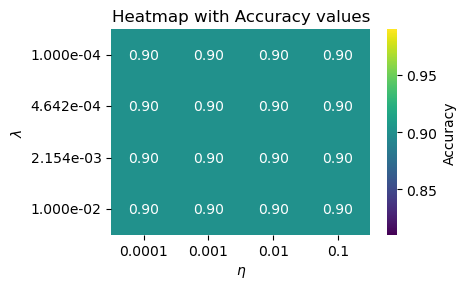

In [32]:

task = 'part_f'
hidden_str = 'hidden_8'
algo = 'ownNN_RELU_L1'
plot_type = 'heatmap'

filename_values = f'{task}-{plot_type}-{hidden_str}-iter{EPOCHS}-batch{number_batch}-{algo}'

plotting.plot_heatmap(applied_df, 'Accuracy',
              y_axis_scientific=True, 
              title='Heatmap with Accuracy values', 
             filename = 'classify_own' + filename_values)

In [ ]:
'''
ETA= 0.5    # eta 0.5 in runge_preprocessing ETAs?

print(f'Dimensions of input, hidden, and output layer:\n{_dim}')
optimizer_ADAM = schedulers.ADAM(eta=ETA_VALUES[2], rho=0, rho2=0) 
optimizer_momentum = schedulers.momentum(eta=ETA, momentum=MOMENTUM)
optimizer_RMSprop = schedulers.RMSprop(eta=ETA,rho=0)

NN_classify = NN.NN(dims = _dim, 
                    activation_funcs = activations,
                    activation_ders = activations_derivative,
                    cost_object=cost_fn,
                    seed=NP_RANDOM_SEED)

'''

Dimensions of input, hidden, and output layer:
[784, 32, 16, 10]
Classification set: True


In [ ]:
'''
epoch_scores, predictions = NN_classify.fit(X=X_train, 
                 t=y_train, 
                epochs=ITERATIONS, 
                batches=number_batch,
                scheduler=optimizer_ADAM,
                X_val=X_test,
                t_val=y_test)

'''


L1 and L2 term
0
0
Using scheduler: ADAM 
